In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn
import scipy 
from scipy.linalg import eigh, cholesky
from scipy.stats import norm
import linearmodels.panel as lmp
from pylab import plot, show, axis, subplot, xlabel, ylabel, grid
import semopy 
import seaborn as sns
from factor_analyzer import FactorAnalyzer
from sklearn.decomposition import PCA
from IPython.display import Image
import warnings


import os

1. Cargue la base de datos y realice los ajustes necesarios para su uso (missing values, recodificar variables, etcetera). Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario.

In [ ]:
df=pd.read_csv("../data/junaeb3.csv")
warnings.filterwarnings('ignore')

In [4]:
df

,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,sk5,...,sk9,sk10,sk11,sk12,sk13,act_fisica,area,educm,educp,madre_work
0,1,85,0.75,1,1,1,1,1,2,1,...,2,2,2,3,2,NaN,0,11.0,11,-1
1,0,76,0.71,0,1,1,1,1,1,1,...,1,1,1,1,1,5.0,0,8.0,8,1
2,1,68,0.27,0,1,2,2,3,2,1,...,2,3,2,1,3,NaN,1,13.0,13,1
3,1,84,2.05,1,1,1,1,1,1,1,...,1,1,1,1,1,2.0,1,16.0,12,-1
4,0,86,1.05,1,1,1,1,1,1,1,...,1,1,1,1,1,1.0,1,17.0,15,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31050,0,78,1.63,1,1,1,3,1,2,2,...,2,2,2,1,1,2.0,1,13.0,13,-1
31051,1,79,2.57,1,1,1,1,2,2,1,...,1,3,2,1,4,3.0,1,18.0,19,0
31052,0,78,2.12,1,1,1,1,1,1,1,...,1,3,1,1,1,3.0,1,13.0,9,1
31053,1,78,-0.43,1,1,1,1,1,1,2,...,1,2,1,1,2,2.0,1,17.0,15,1


In [5]:
nan_porcentaje = df.isna().mean().sort_values() * 100
print(nan_porcentaje)

sexo          0.000000
edad          0.000000
imce          0.000000
vive_padre    0.000000
vive_madre    0.000000
sk1           0.000000
sk2           0.000000
sk3           0.000000
sk4           0.000000
sk5           0.000000
sk6           0.000000
sk7           0.000000
sk8           0.000000
sk9           0.000000
sk10          0.000000
sk11          0.000000
sk12          0.000000
sk13          0.000000
area          0.000000
educp         0.000000
madre_work    0.000000
educm         1.201095
act_fisica    3.232974
dtype: float64


In [6]:
df.dropna(inplace=True)

In [7]:
df.describe()

,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,sk5,...,sk9,sk10,sk11,sk12,sk13,act_fisica,area,educm,educp,madre_work
count,29696.000000,29696.000000,29696.00000,29696.000000,29696.000000,29696.000000,29696.000000,29696.000000,29696.000000,29696.000000,...,29696.000000,29696.000000,29696.000000,29696.000000,29696.000000,29696.000000,29696.000000,29696.000000,29696.000000,29696.000000
mean,0.539164,82.544450,1.01826,0.720097,0.975990,1.108533,1.386651,1.256802,1.250943,1.264749,...,1.326307,1.844693,1.379108,1.495858,1.687298,2.556270,0.911705,13.106311,13.001785,0.106917
std,0.498472,4.295051,1.36947,0.449559,0.164329,0.379168,0.643343,0.575636,0.569647,0.558138,...,0.655108,0.933154,0.660226,0.790316,0.979401,1.067923,0.283728,3.328273,3.418317,0.941629
min,0.000000,62.000000,-5.02000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,-1.000000
25%,0.000000,80.000000,0.12000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,12.000000,11.000000,-1.000000
50%,1.000000,81.000000,0.98000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,13.000000,13.000000,1.000000
75%,1.000000,82.000000,1.93000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,...,1.000000,2.000000,2.000000,2.000000,2.000000,3.000000,1.000000,15.000000,15.000000,1.000000
max,1.000000,107.000000,5.04000,2.000000,2.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1.000000,22.000000,22.000000,1.000000


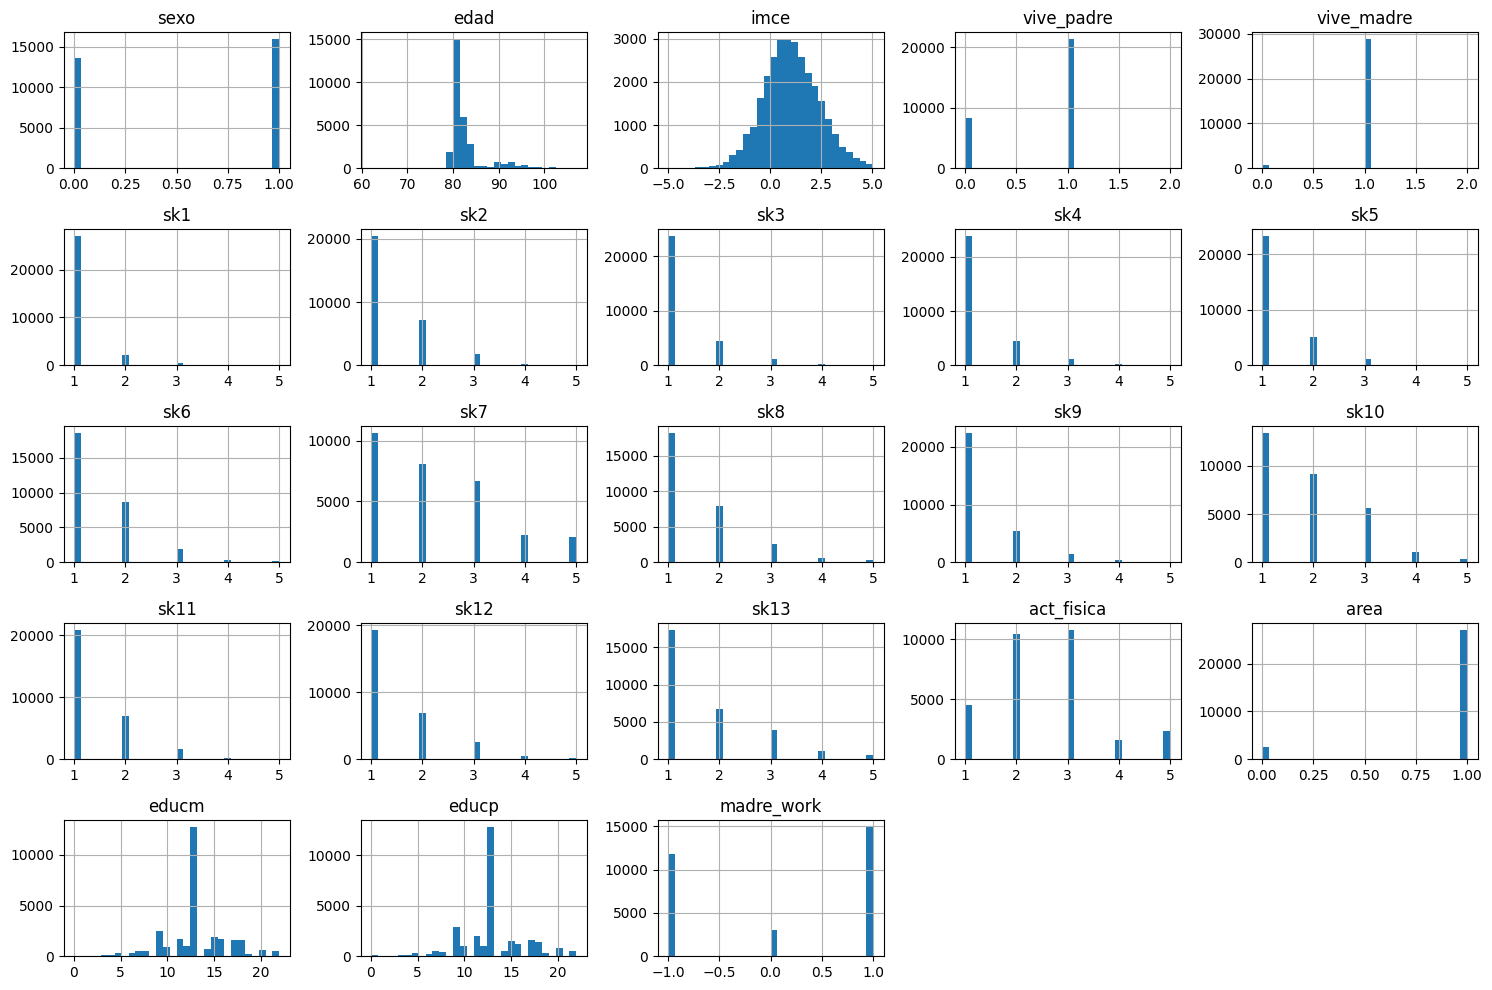

In [8]:
#Creamos gráficos de barra para observar las distriuciones de nuestras variables de manera general
df.select_dtypes(include=['float64', 'int64']).hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()

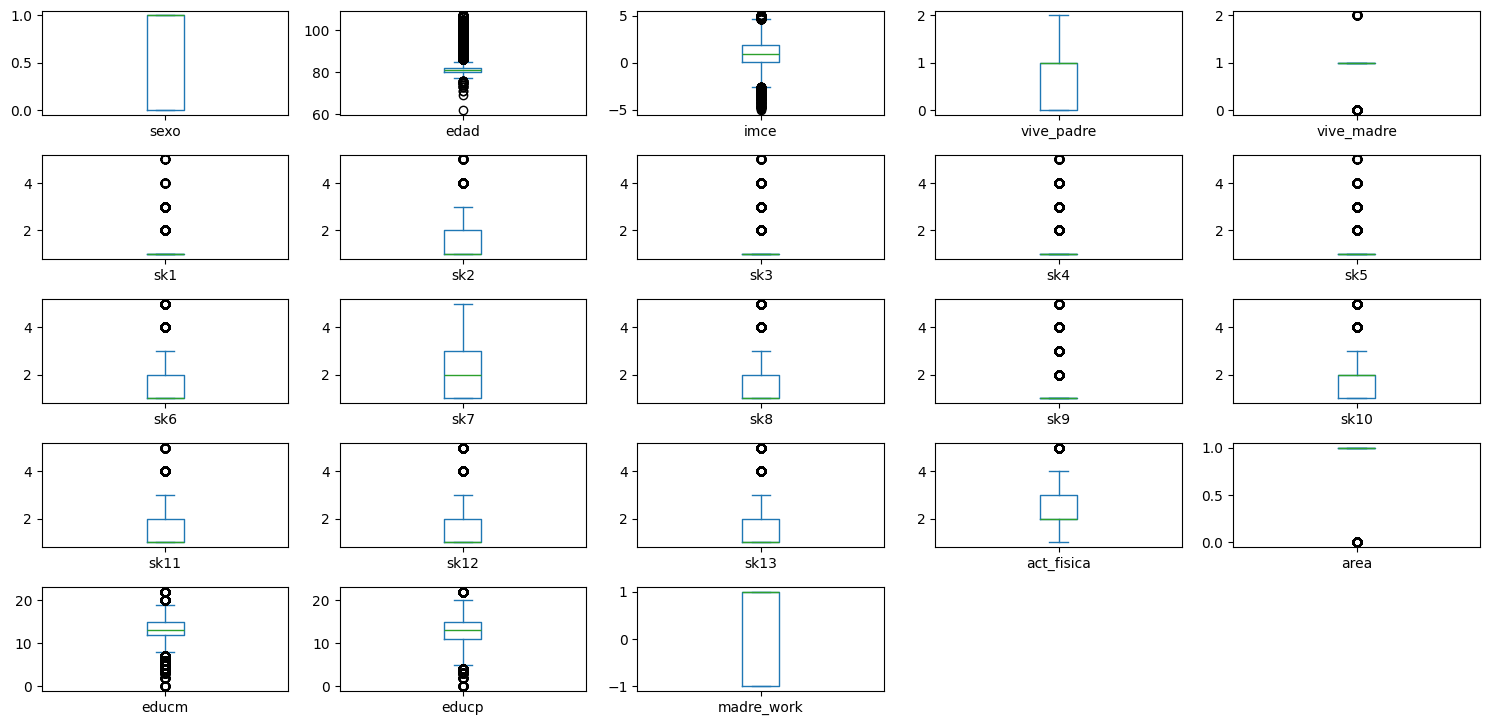

In [9]:
#Hacemos lo mismo pero con graficos de caja para observar datos extremos
df.select_dtypes(include=['float64', 'int64']).plot(kind='box', subplots=True, layout=(7, 5), figsize=(15, 10), sharex=False, sharey=False)
plt.tight_layout()
plt.show()

R: No se observa ningún outlier que pueda afectar el analisis de los datos. Simplemente se limpian los NaN. Las edades son acordes a los años en meses para los niños, las preguntas sk están dentro de sus rangos, imce y educ entre otras también están en los rangos esperados.

2. A partir de las variables sk1-sk13 realice un EFA. En particular determine el numero optimo de factores y reporte las variables que se asocian a cada factor (usando los factor loadings). Tambien discuta si existen variables que no son informativas. (Hint: para realizar un EFA, todas las variables deben estar representatadas en el mismo sentido logico. Si una carateristica es negativa debe ser invertida en la escala, de tal forma que todas las variables representen aspectos positivos).

In [10]:
df_sk = df[['sk1', 'sk2', 'sk3', 'sk4', 'sk5', 'sk6', 'sk8', 'sk9', 'sk10', 'sk11', 'sk12', 'sk13']]
df_sk.describe()

,sk1,sk2,sk3,sk4,sk5,sk6,sk8,sk9,sk10,sk11,sk12,sk13
count,29696.000000,29696.000000,29696.000000,29696.000000,29696.000000,29696.000000,29696.000000,29696.000000,29696.000000,29696.000000,29696.000000,29696.000000
mean,1.108533,1.386651,1.256802,1.250943,1.264749,1.483803,1.550748,1.326307,1.844693,1.379108,1.495858,1.687298
std,0.379168,0.643343,0.575636,0.569647,0.558138,0.734547,0.827738,0.655108,0.933154,0.660226,0.790316,0.979401
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000
75%,1.000000,2.000000,1.000000,1.000000,1.000000,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000,2.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [11]:
df_sk

,sk1,sk2,sk3,sk4,sk5,sk6,sk8,sk9,sk10,sk11,sk12,sk13
1,1,1,1,1,1,1,1,1,1,1,1,1
3,1,1,1,1,1,1,1,1,1,1,1,1
4,1,1,1,1,1,1,1,1,1,1,1,1
5,1,2,1,1,1,1,1,1,1,1,1,1
6,1,1,1,2,2,2,2,3,3,3,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...
31050,1,3,1,2,2,1,3,2,2,2,1,1
31051,1,1,2,2,1,1,2,1,3,2,1,4
31052,1,1,1,1,1,1,1,1,3,1,1,1
31053,1,1,1,1,2,2,2,1,2,1,1,2


In [12]:
fa = FactorAnalyzer(rotation='oblimin').fit(df_sk) #Aplicamos analisis factorial y rotamos por varimax

In [13]:
np.set_printoptions(suppress=True, formatter={'float_kind':'{:f}'.format}) #Nos muestra la cantidad de varianza explicada por los factores para cada variable
fa.loadings_

array([[0.025091, 0.592769, -0.036490],
       [0.014132, 0.504176, 0.201440],
       [0.015141, 0.633897, -0.014981],
       [0.001552, 0.742733, -0.011935],
       [-0.030999, 0.020518, 0.804761],
       [0.081477, 0.098873, 0.419382],
       [0.231480, -0.072300, 0.454024],
       [0.502530, 0.074356, 0.049459],
       [0.610043, -0.023017, -0.033028],
       [0.704005, 0.033629, 0.005354],
       [0.570888, -0.038834, 0.007890],
       [0.508570, 0.028714, -0.008627]])

De aquí obtuvimos que sk7 tenía cargas bajas, por lo que lo elimino en las celdas de arriba.

In [14]:
fa.get_eigenvalues() #Obtenemos los autovalores de cada factor. A partir del criterio de kaiser mantenemos los que son >1. Indican cuanta varianza explica cada factor

(array([4.003739, 1.347633, 1.089935, 0.802648, 0.743580, 0.706589,
        0.691043, 0.610450, 0.531272, 0.519068, 0.491722, 0.462321]),
 array([3.392029, 0.739425, 0.534958, 0.139459, 0.078895, 0.040789,
        -0.022950, -0.044788, -0.059629, -0.082529, -0.108439, -0.180479]))

In [15]:
fa.get_communalities() #Indica cuanto % de varianza de esa variable está explicada por los factores

array([0.353336, 0.294971, 0.402279, 0.551797, 0.649022, 0.192296,
       0.264948, 0.260512, 0.373773, 0.496782, 0.327484, 0.259543])

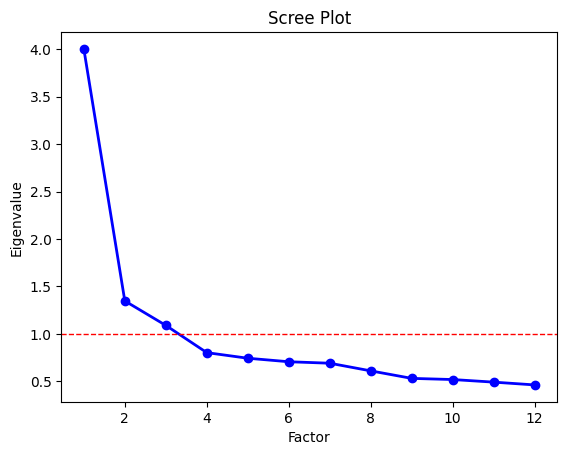

In [16]:
values = np.arange(1,13)
eigenvalues = pd.DataFrame(data=fa.get_eigenvalues())
plt.plot(values, eigenvalues.loc[0], 'o-', linewidth=2, color='blue')  #Usamos solo la fila de los autovalores
plt.axhline(y=1, color='red', linestyle='--', linewidth=1)
plt.title('Scree Plot')
plt.xlabel('Factor')
plt.ylabel('Eigenvalue')
plt.show()

In [17]:
fa.get_factor_variance() #La primera fila indica cuantas unidades de varianza explica cada factor, la segunda indica cuanta proporcion de la varianza es explicada por cada factor 
                            #y la tercera es la prop acumulada

(array([1.767112, 1.583991, 1.075638]),
 array([0.147259, 0.131999, 0.089636]),
 array([0.147259, 0.279259, 0.368895]))

In [18]:
print(semopy.efa.explore_cfa_model(df_sk, pval=0.05)) #eta1 lado más artistico? emocional? de interés
                                                      #eta2 amabilidad? que tan no agresivo es y que tanto comparte
                                                      #eta3 

eta1 =~ sk11 + sk9 + sk10 + sk12
eta2 =~ sk4 + sk2 + sk11 + sk5 + sk3 + sk9 + sk1 + sk6 + sk8 + sk12
eta3 =~ sk11 + sk12 + sk13



R: A partir del factor loading obtuvimos las siguientes cargas de las variables en los factores: 

F2 tiene cargas fuertes de: sk1, sk2, sk3, sk4. Este factor se asocia a si expresa sus sentimientos.

F1 tiene cargas fuertes de: sk9, sk10, sk11, sk12 y sk 13. Este factor hace referencia al interés.

F3 de sk5, sk6 y sk8. Este factor se asocia a sus habilidades para desenvolverse en grupos.

Utilizamos una rotación "oblimin" ya que nos permite que exista correlación entre los factores. Las variables "sk" representan caracteristicas psicosociales de los niños que no son completamente independientes entre si. También nos permite ver como cada variable no solo aporta a un factor si no también como lo perjudica (cargas negativas).

Para determinar el número de factores óptimo se consdieró el criterio de Kaiser de eigenvalues >1, para esto se utilizó un gráfico de codo y se incluyó una recta en y=1 para poder visualizar de mejor manera la cantidad de factores a considerar. Determinamos que 3 son adecuados ya que desde el 4to factor se encuentra bajo el criterio de >1.

Puede ser que el sk6 y sk8 no sean tan informativas (no tienen cargas muy grandes).

3. Con los resultados de la Pregunta 2, graficamente indique si existen diferencias significativas en la distribucion de los factores usando las siguientes variables para caracterizar: sexo, area, imce y act_fisica (Hint: usar scatterplot de factores en pares, y ocupar la opcion 'hue' para agregar variables de caracterizacion). Que puede concluir de los resultados?

In [19]:
factor_scores = fa.transform(df_sk) #Asignamos la puntuación de cada individuo en cada factor a partir de sus respuestas en las preguntas.
factor_scores

array([[-0.867466, -0.616281, -0.638919],
       [-0.867466, -0.616281, -0.638919],
       [-0.867466, -0.616281, -0.638919],
       ...,
       [-0.413135, -0.576245, -0.633808],
       [-0.283813, -0.377351, 0.832745],
       [-0.725359, 0.251866, -0.422317]], shape=(29696, 3))

In [20]:
import pandas as pd

# Crear DataFrame con los scores
df_scores = pd.DataFrame(factor_scores, columns=['F1', 'F2', 'F3'])

df_carp3 = df[['sexo', 'area', 'imce', 'act_fisica']]
df_carp3

df_p3 = pd.concat([df_scores, df_carp3.reset_index(drop=True)], axis=1)
df_p3

,F1,F2,F3,sexo,area,imce,act_fisica
0,-0.867466,-0.616281,-0.638919,0,0,0.71,5.0
1,-0.867466,-0.616281,-0.638919,1,1,2.05,2.0
2,-0.867466,-0.616281,-0.638919,0,1,1.05,1.0
3,-0.811243,-0.285673,-0.452383,0,0,1.39,4.0
4,1.825799,0.618602,1.100493,1,1,2.75,2.0
...,...,...,...,...,...,...,...
29691,0.572902,0.995480,1.344394,0,1,1.63,2.0
29692,0.867694,0.643886,-0.273191,1,1,2.57,3.0
29693,-0.413135,-0.576245,-0.633808,0,1,2.12,3.0
29694,-0.283813,-0.377351,0.832745,1,1,-0.43,2.0


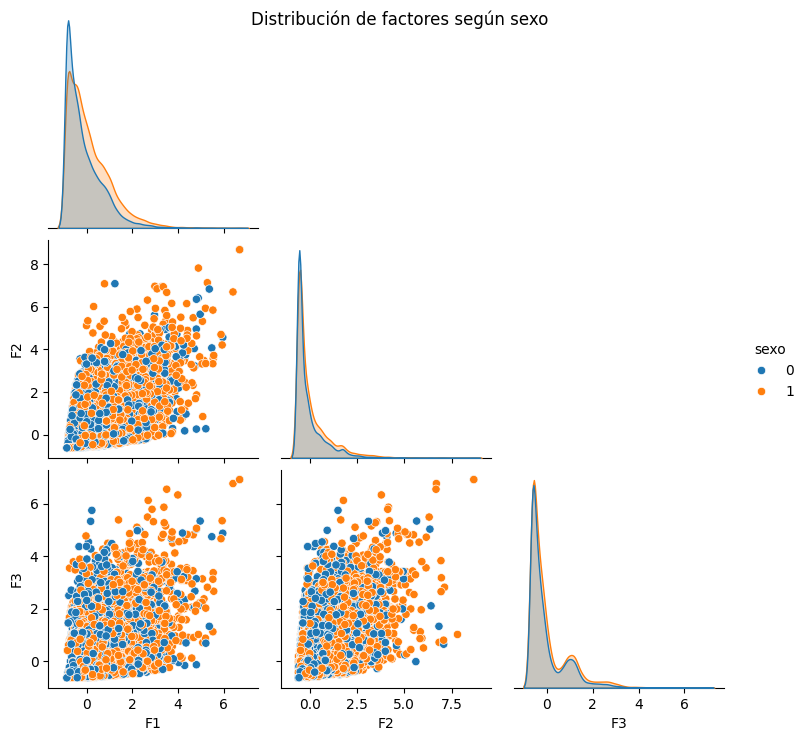

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df_p3, vars=['F1', 'F2', 'F3'], hue='sexo', corner=True)
plt.suptitle("Distribución de factores según sexo")
plt.show()


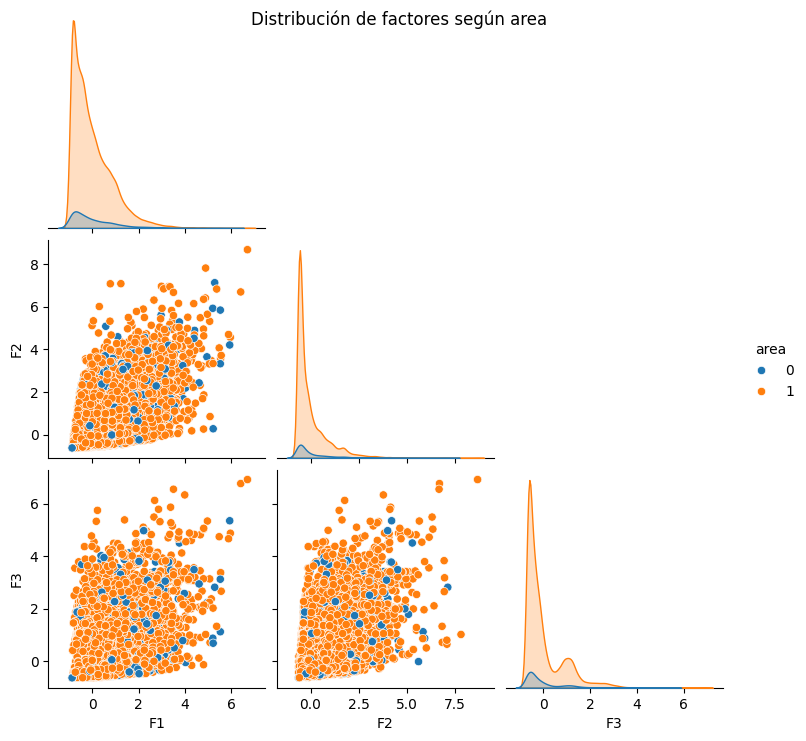

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df_p3, vars=['F1', 'F2', 'F3'], hue='area', corner=True)
plt.suptitle("Distribución de factores según area")
plt.show()

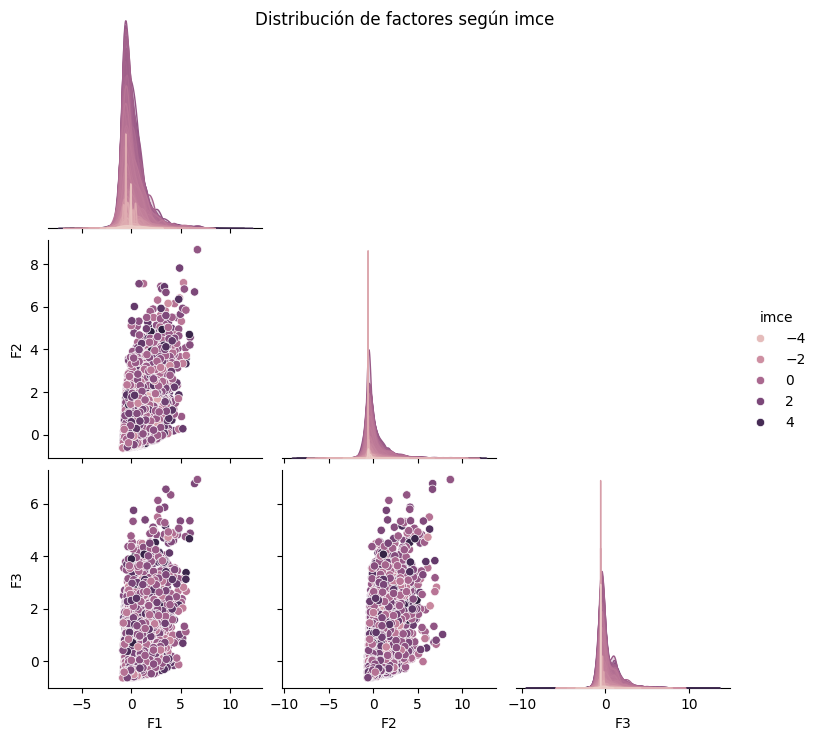

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df_p3, vars=['F1', 'F2', 'F3'], hue='imce', corner=True)
plt.suptitle("Distribución de factores según imce")
plt.show()


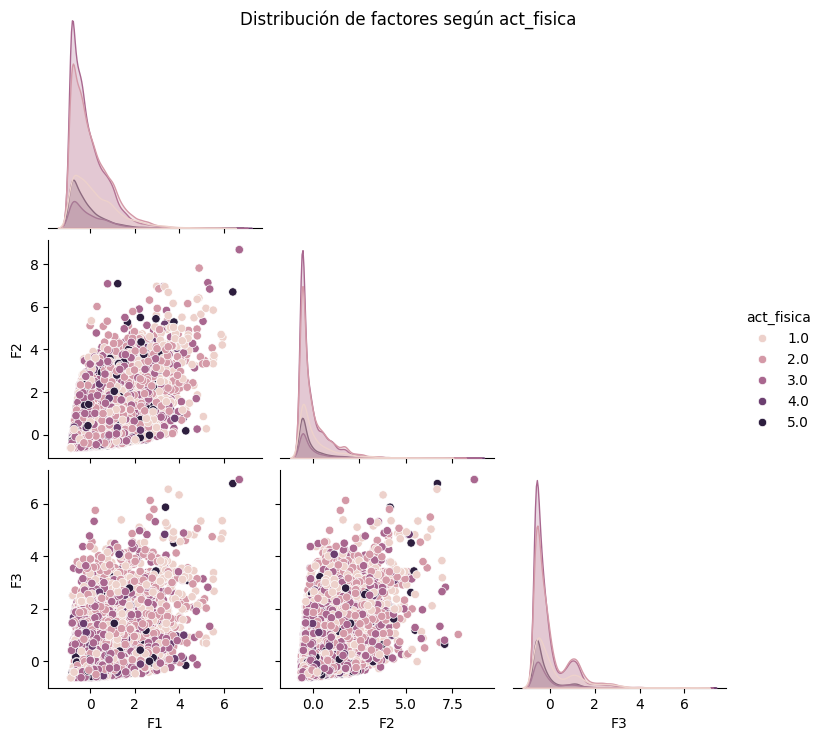

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df_p3, vars=['F1', 'F2', 'F3'], hue='act_fisica', corner=True)
plt.suptitle("Distribución de factores según act_fisica")
plt.show()

R: En los gráficos obtenidos no se evidencia una separación clara entre los grupos. Los datos se distribuyen de manera similar en los distintos valores de las variables, sin observarse agrupaciones diferenciadas.

4. Con los resultados obtenidos en la Pregunta 2, proponga un CFA donde cada variable solo se asocia con un factor. Entregue un nombre a cada factor que representa el concepto comun entre las variables incluidas. Reporte la importancia de cada medida (variable) a cada factor e indique la correlacion entre factores (loadings).

In [25]:
mod = """
Interes =~ sk9 + sk10 + sk11 + sk12 + sk13
ExpresaSentimientos =~ sk1 + sk2 + sk3 + sk4
Comparte =~ sk5 + sk6 + sk8
    """

model = semopy.Model(mod)
out=model.fit(df_sk)
print(out)

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.143
Number of iterations: 41
Params: 1.348 1.248 1.097 1.274 1.877 1.646 1.846 1.020 1.158 0.161 0.057 0.091 0.049 0.051 0.152 0.095 0.595 0.200 0.442 0.713 0.242 0.199 0.158 0.151 0.372 0.469 0.277


In [26]:

model.inspect(mode='list', what="names", std_est=True)

,lval,op,rval,Estimate,Est. Std,Std. Err,z-value,p-value
0,sk9,~,Interes,1.000000,0.594425,-,-,-
1,sk10,~,Interes,1.348296,0.562596,0.01854,72.725071,0.0
2,sk11,~,Interes,1.247906,0.736003,0.014736,84.684717,0.0
3,sk12,~,Interes,1.097330,0.540702,0.015523,70.692694,0.0
4,sk13,~,Interes,1.273586,0.506374,0.018913,67.339241,0.0
5,sk1,~,ExpresaSentimientos,1.000000,0.582652,-,-,-
6,sk2,~,ExpresaSentimientos,1.876642,0.644548,0.023793,78.87212,0.0
7,sk3,~,ExpresaSentimientos,1.646084,0.631816,0.021121,77.934883,0.0
8,sk4,~,ExpresaSentimientos,1.845637,0.715782,0.022169,83.253688,0.0
9,sk5,~,Comparte,1.000000,0.718118,-,-,-


In [27]:
semopy.calc_stats(model)

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,51,66,4252.869542,0.0,80903.16637,0.948021,0.947433,0.931972,0.947433,0.932733,0.052674,53.713573,277.780299,0.143214


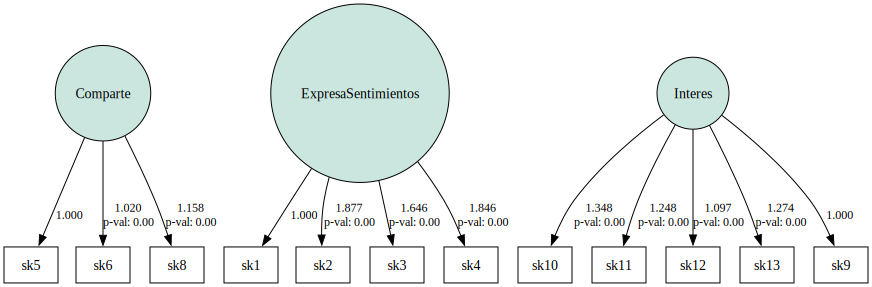

In [28]:
semopy.semplot(model, "model.png")

R: Para analizar encontrar la correlación entre factores buscamos los valores "~~"" que indican una covarianza. Y para cuantificar su valor observamos Est. Std, que entrega las correlaciones estandarizadas.
ExpresaSentimientos con Comparte tiene una correlación positiva de 0.65.

ExpresaSentimientos con Interes tiene una correlación positiva de 0.6.

Interes con Comparte tiene una correlación positiva de 0.58.

De acuerdo a la importancia de cada medida para cada factor tenemos:
Factor interés: Importancia alta en las variables de la sk9 a la sk13, tienen en promedio un valor de 1.2. Indicando que si el factor aumenta en 1 unidad estas variables aumentan en 1.2 unidades.

Factor ExpresaSentimientos: Immportancia más alta en las variables en comparación que en el Factor interés. De sk1 a sk4 se tiene un promedio de 1.7 aproximadamente 

Factor Comparte: Presenta importancia alta, de sk5 a sk8 presenta valor promedio de 1.1.

En conclusión todas las variables tienen cargas importantes en sus factores, contribuyendo significativamente.

5. Estime un modelo de clases latentes usando imce via StepMix. Determine el numero optimo de clases (clusters) y muestre las diferencias entre clusters graficamente. Que se puede concluir de los resultados?

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:01<00:00,  1.47s/it, max_LL=-5.18e+4, max_avg_LL=-1.74]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:03<00:00,  3.92s/it, max_LL=-5.14e+4, max_avg_LL=-1.73]


Fitting StepMix...


...

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:18<00:00, 18.72s/it, max_LL=-5.13e+4, max_avg_LL=-1.73]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:21<00:00, 21.62s/it, max_LL=-5.13e+4, max_avg_LL=-1.73]


<Axes: >

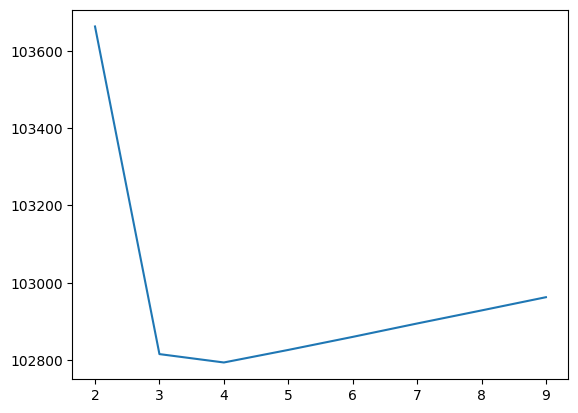

In [29]:
from stepmix.stepmix import StepMix
dflc=df
dflcime=dflc[['imce']]
# Numero optimo de clusters
K = range(2, 10)
fits = []
BIC = []

for k in K:
    # train the model for current value of k on training data
    model = StepMix(n_components=k, measurement='gaussian', verbose=0, random_state=123).fit(dflcime)
    
    # append the model to fits
    fits.append(model)
    
    # Append the silhouette score to scores
    BIC.append(model.sabic(dflcime))

sns.lineplot(x = K, y = BIC)

In [30]:
from stepmix.stepmix import StepMix
model = StepMix(n_components=3, measurement="gaussian", verbose=1, random_state=123).fit(dflcime)

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:04<00:00,  4.57s/it, max_LL=-5.14e+4, max_avg_LL=-1.73]

MODEL REPORT
    Measurement model parameters
          model_name     gaussian_unit                
          class_no                   0       1       2
          param variable                              
          means imce            -1.949  2.4056  0.5984
    Class weights
        Class 1 : 0.02
        Class 2 : 0.27
        Class 3 : 0.71
    Fit for 3 latent classes
    Estimation method             : 1-step
    Number of observations        : 29696
    Number of latent classes      : 3
    Number of estimated parameters: 5
    Log-likelihood (LL)           : -51364.3251
    -2LL                          : 102728.6503
    Average LL                    : -1.7297
    AIC                           : 102738.65
    BIC                           : 102780.14
    CAIC                          : 102785.14
    Sample-Size Adjusted BIC      : 102815.75
    Entropy                       : 11499.4902
    Scaled Relative Entropy       : 0.6475


In [31]:
#Predict clusters
dflcime['pred']=model.predict(dflcime)

<Axes: xlabel='pred', ylabel='imce'>

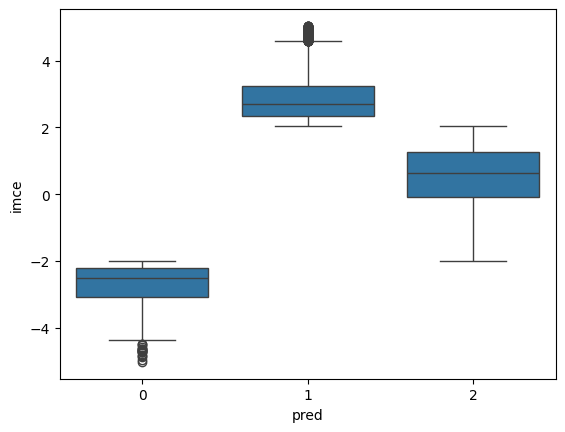

In [32]:
sns.boxplot(x='pred', y='imce', data=dflcime)

R: Para determinar el número de clusters adecuado primero analizamos de acuerdo al BIC que rpresenta que tan bien se ajusta el modelo a los datos, a menos BIC mejor se ajusta. Para visualizar esto graficamos los BIC y observamos que los menores valores se encuentran en 3 y 4 clusters, después de esos el BIC vuelve a aumentar. Para diferenciar entre estos dos lo que se hizo fue analizar sus entropías relativas, donde los valores varían entre 0 y 1, mientras mas cerca del 1 mas clara es la asignación de las personas a las clases.

Con 3 clusters tenemos entropia relativa = 0.6495 y con 4 clusters tenemos 0.422. Con 4 clusters a pesar de tener un BIC levemente menor, tenemos una entropia relativa relativamente baja en comparación a con 3 clusters, por lo tanto elegimos 3 clusters para el modelo.

Del modelo ejecutado con 3 clusters obtenemos las siguientes clases:

Clase 1: Promedio imce = 2.4 y peso de 0.27. Esto nos indica que esta clase representa un 27% de la muestra y que se encuentra 2.4 unidades de desviación estandar sobre la media, que sugiere posible sobrepeso u obesidad.

Clase 2: Promedio imce = 0.5922. y peso de 0.71. Esto nos indica que esta clase representa un 71% de la muestra y que se encuentra 0.5922 unidades de desviación estandar sobre la media, sugiriendo un IMC normal o sobrepeso leve.

Clase 3: Promedio imce = -1.9669 y peso de 0.02. Esto nos indica que esta clase representa un 2% de la muestra y que se encuentra -1.9669 unidades de desviación estandar sobre la media (indica desnutrición).

De esto podemos concluir la mayoría (Clase 2) se encuentra levemente sobre la media de IMC que es normal. Por otro lado una gran parte de la muestra (Clase 1) se encuentra con un altisimo nivel de IMC, indicando un posible sobrepeso. Por el otro extremo tenemos una leve porción del total con valores bastante bajos indicando que se encuentran en posible desnutrición.



6. Implemente un SEM completo usando la estructura propuesta en la Pregunta 4. En particular, estime un modelo donde los factores latentes explican el imce, junto con otras variables que existen en la base de datos. Ademas utilice otras variables relevantes de la base de datos para su modelo. Las variables a incluir en el modelo final deben tener sustento teorico y el modelo final debe optimizar el ajuste a los datos, en base a los criterios vistos en clase (TLI, CLI, RMSEA). Que puede concluir en base a sus resultados?

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.336
Number of iterations: 52
Params: -0.307 0.240 -0.049 -0.015 -0.006 0.042 0.135 -0.023 1.348 1.247 1.097 1.273 1.878 1.646 1.846 1.020 1.160 0.161 0.057 0.091 0.049 0.051 0.152 1.861 0.095 0.595 0.200 0.442 0.713 0.242 0.199 0.158 0.151 0.373 0.469 0.277
                   lval  op                 rval  Estimate  Std. Err  \
0                  imce   ~  ExpresaSentimientos -0.307454   0.07032   
1                  imce   ~             Comparte  0.239747  0.040607   
2                  imce   ~              Interes -0.048570  0.035655   
3                  imce   ~                educp -0.015477  0.002886   
4                  imce   ~                educm -0.005974  0.003043   
5                  imce   ~           madre_work  0.042406  0.008793   
6                  imce   ~                 sexo  0.135103  0.015916   
7                  imce   ~        

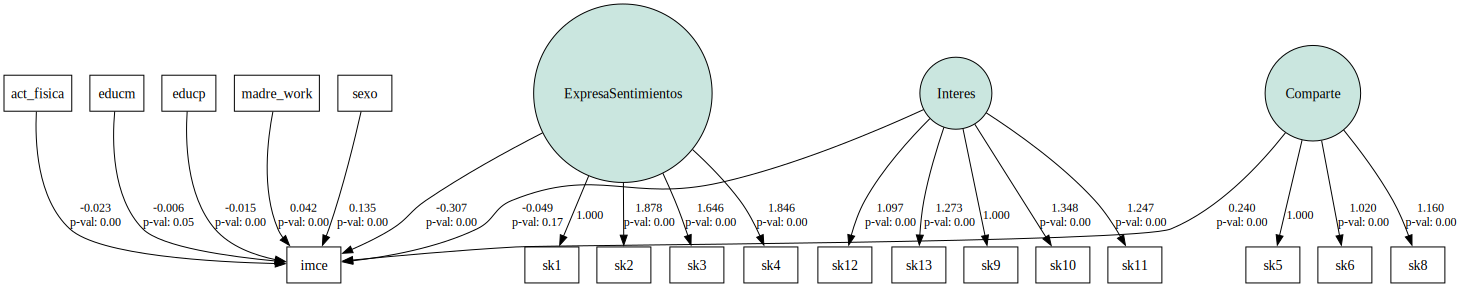

In [33]:
mod = """
# Structural model
imce ~ ExpresaSentimientos + Comparte + Interes + educp + educm + madre_work + sexo + act_fisica


# Measurement Part
Interes =~ sk9 + sk10 + sk11 + sk12 + sk13
ExpresaSentimientos =~ sk1 + sk2 + sk3 + sk4
Comparte =~ sk5 + sk6 + sk8
    """

model = semopy.Model(mod)
out=model.fit(df)
print(out)
print(model.inspect())
semopy.semplot(model, "semmodel.png")

In [34]:
semopy.calc_stats(model)

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,135,158,9985.21789,0.0,102551.891026,0.903801,0.902633,0.886044,0.902633,0.887411,0.049569,71.327504,370.083139,0.336248


R: Se consideraron las variables educ (para madre y padre), madre_work, sexo, act_fisica. 
Considero que la variable de educación de los padres se ve reflejada en el IMC de los niños, ya que al poseer una mayor educación pueden ser conscientes de las enfermedades y efectos que traen no tener una alimentación saludable. 
Para la variable madre_work considero que es relevante para la alimentación del niño ya que puede estar acompañandolo en el día a día y preocuparse de que coma bien.
Por otro lado considero la variable sexo importante para el IMC ya que por lo "general", los niños suelen hacer más deporte y a jugar de forma más activa, lo que reduciría el IMC.
Y por último la variable que considero más importane es act_física ya que se relaciona directamente con el consumo energetico del individuo.

En cuanto a los ajustes del modelo, se obtuvo valores altos tanto en CFI como TLI, con ambos alrededor de 0.9, con una leve diferencia menor en TLI. Estos valores nos indican la comparación de nuestro modelo frente a un modelo nulo (que no considera que las variables se relacionan), sin embargo el TLI penaliza por la complejidad por eso obtenemos un valor levemente menor (para que no se ajuste tanto a los datos). Por otro lado tenemos el RMSEA con un valor de 0.049, se considera un valor recomendable ya que esta metrica representa que tan bien se ajusta el modelo a los datos.

7. Repita el analisis de la Pregunta 6 usando para cada submuestra generada a partir de las clases latentes obtenida en la pregunta 5. Reporte diferencias entre los parametros entre los distintos grupos (si existieran). Hay alguna ganancia de estimar el modelo por grupos versus el modelo general?

In [35]:
dflcime2=dflcime.drop("imce", axis=1)
dfwpred=pd.concat([df,dflcime2], axis=1)
dfwpred

,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,sk5,...,sk10,sk11,sk12,sk13,act_fisica,area,educm,educp,madre_work,pred
1,0,76,0.71,0,1,1,1,1,1,1,...,1,1,1,1,5.0,0,8.0,8,1,2
3,1,84,2.05,1,1,1,1,1,1,1,...,1,1,1,1,2.0,1,16.0,12,-1,1
4,0,86,1.05,1,1,1,1,1,1,1,...,1,1,1,1,1.0,1,17.0,15,0,2
5,0,74,1.39,1,1,1,2,1,1,1,...,1,1,1,1,4.0,0,8.0,8,-1,2
6,1,91,2.75,1,1,1,1,1,2,2,...,3,3,2,2,2.0,1,20.0,19,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31050,0,78,1.63,1,1,1,3,1,2,2,...,2,2,1,1,2.0,1,13.0,13,-1,2
31051,1,79,2.57,1,1,1,1,2,2,1,...,3,2,1,4,3.0,1,18.0,19,0,1
31052,0,78,2.12,1,1,1,1,1,1,1,...,3,1,1,1,3.0,1,13.0,9,1,1
31053,1,78,-0.43,1,1,1,1,1,1,2,...,2,1,1,2,2.0,1,17.0,15,1,2


In [36]:
cluster_0 = dfwpred[dfwpred["pred"] == 0] #Bajo peso
cluster_1 = dfwpred[dfwpred["pred"] == 1] #sobrepeso
cluster_2 = dfwpred[dfwpred["pred"] == 2] #normal


Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.682
Number of iterations: 53
Params: 1.027 -0.403 -0.063 -0.003 0.027 0.021 -0.083 0.093 1.046 1.112 0.825 1.073 2.464 2.202 2.776 1.085 1.313 0.152 0.048 0.093 0.028 0.047 0.225 0.461 0.081 0.656 0.216 0.349 0.762 0.241 0.198 0.138 0.165 0.409 0.533 0.279
                   lval  op                 rval  Estimate  Std. Err  \
0                  imce   ~  ExpresaSentimientos  1.026963  0.518477   
1                  imce   ~             Comparte -0.403129  0.212449   
2                  imce   ~              Interes -0.063033  0.115754   
3                  imce   ~                educp -0.002748  0.012598   
4                  imce   ~                educm  0.026570  0.013115   
5                  imce   ~           madre_work  0.020908  0.037225   
6                  imce   ~                 sexo -0.083015  0.069991   
7                  imce   ~         

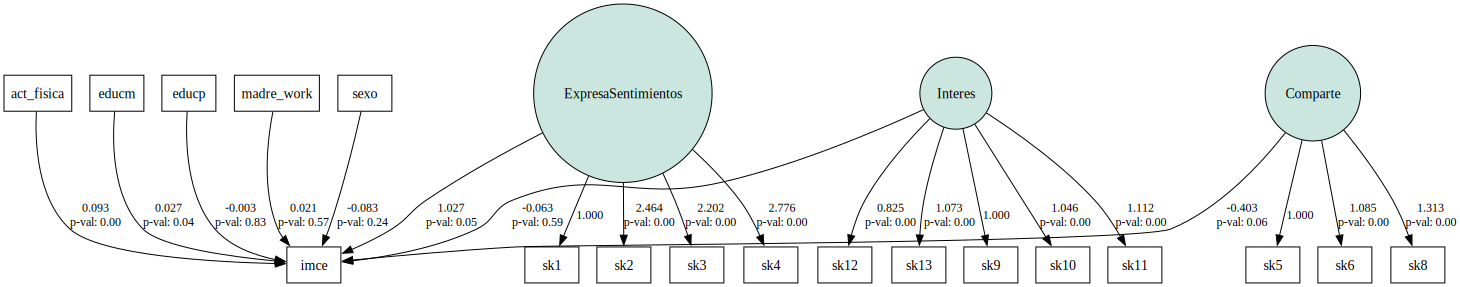

In [37]:
mod = """
# Structural model
imce ~ ExpresaSentimientos + Comparte + Interes + educp + educm + madre_work + sexo + act_fisica


# Measurement Part
Interes =~ sk9 + sk10 + sk11 + sk12 + sk13
ExpresaSentimientos =~ sk1 + sk2 + sk3 + sk4
Comparte =~ sk5 + sk6 + sk8
    """

model = semopy.Model(mod)
out=model.fit(cluster_0)
print(out)
print(model.inspect())
semopy.semplot(model, "semmodel.png")

In [38]:
semopy.calc_stats(model)

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,135,158,282.518089,1.784017e-12,1639.097064,0.900399,0.827638,0.798273,0.827638,0.88343,0.051438,70.635178,215.566353,0.682411


Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.368
Number of iterations: 43
Params: -0.173 0.160 -0.038 -0.004 -0.008 -0.007 0.178 -0.004 1.364 1.242 1.143 1.360 1.807 1.482 1.648 0.976 1.106 0.186 0.065 0.099 0.057 0.055 0.156 0.444 0.096 0.625 0.211 0.469 0.741 0.245 0.216 0.160 0.165 0.397 0.524 0.273
                   lval  op                 rval  Estimate  Std. Err  \
0                  imce   ~  ExpresaSentimientos -0.172532  0.064263   
1                  imce   ~             Comparte  0.159600  0.038003   
2                  imce   ~              Interes -0.037802  0.035595   
3                  imce   ~                educp -0.004454  0.002906   
4                  imce   ~                educm -0.008377  0.003054   
5                  imce   ~           madre_work -0.007025   0.00909   
6                  imce   ~                 sexo  0.178181  0.016677   
7                  imce   ~       

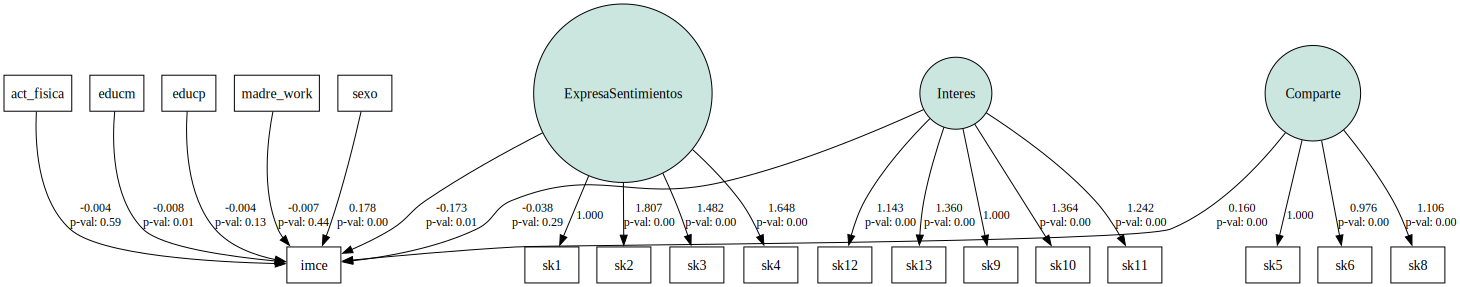

In [39]:
mod = """
# Structural model
imce ~ ExpresaSentimientos + Comparte + Interes + educp + educm + madre_work + sexo + act_fisica


# Measurement Part
Interes =~ sk9 + sk10 + sk11 + sk12 + sk13
ExpresaSentimientos =~ sk1 + sk2 + sk3 + sk4
Comparte =~ sk5 + sk6 + sk8
    """

model = semopy.Model(mod)
out=model.fit(cluster_1)
print(out)
print(model.inspect())
semopy.semplot(model, "semmodel.png")

In [40]:
semopy.calc_stats(model)

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,135,158,2458.852902,0.0,23071.686828,0.898582,0.893426,0.875268,0.893426,0.881304,0.050771,71.263706,316.305754,0.368147


Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.335
Number of iterations: 45
Params: -0.056 0.016 -0.024 -0.010 0.001 0.020 -0.024 -0.003 1.347 1.252 1.089 1.248 1.890 1.691 1.899 1.034 1.174 0.153 0.055 0.088 0.047 0.050 0.149 0.823 0.095 0.585 0.196 0.435 0.704 0.241 0.194 0.157 0.147 0.364 0.451 0.279
                   lval  op                 rval  Estimate  Std. Err  \
0                  imce   ~  ExpresaSentimientos -0.055599  0.055062   
1                  imce   ~             Comparte  0.016159  0.031852   
2                  imce   ~              Interes -0.023538   0.02755   
3                  imce   ~                educp -0.010116  0.002215   
4                  imce   ~                educm  0.000882  0.002338   
5                  imce   ~           madre_work  0.019760  0.006696   
6                  imce   ~                 sexo -0.023800  0.012102   
7                  imce   ~        

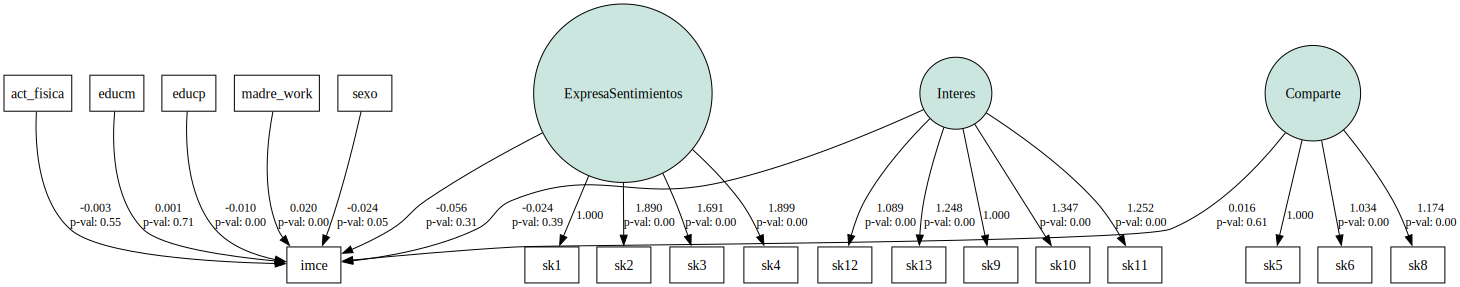

In [41]:
mod = """
# Structural model
imce ~ ExpresaSentimientos + Comparte + Interes + educp + educm + madre_work + sexo + act_fisica


# Measurement Part
Interes =~ sk9 + sk10 + sk11 + sk12 + sk13
ExpresaSentimientos =~ sk1 + sk2 + sk3 + sk4
Comparte =~ sk5 + sk6 + sk8
    """

model = semopy.Model(mod)
out=model.fit(cluster_2)
print(out)
print(model.inspect())
semopy.semplot(model, "semmodel.png")

In [42]:
semopy.calc_stats(model)

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,135,158,7564.865635,0.0,78249.395825,0.904857,0.903324,0.886853,0.903324,0.888647,0.049346,71.330632,360.260797,0.334684


R: Comparando las métricas de los modelos no se observan cambios significativos en CFI, TLI y RMSEA, indicando el modelo ajusta de forma similar los distintos subgrupos. De esta forma podemos concluir que el modelo general ajusta los datos de igual forma que de los modelos por separado. En el modelo del cluster de desnutrición obtenemos un valor objetivo mayor que en el de los demás y el general. Esto puede darse dado que este cluster posee un 2% de la muestra, que puede influenciarce por el ruido y menos estabilidad estadistica. 